# Train / test temporal overlap — DCLDE 2027 `full_train` vs holdout

**Question:** the `full_train` split labels every annotation `train` or `test` (`test` = holdout).
The assignment is made per *audio file*. How much do the `train` and `test` sets bleed into each
other in **time** — files in the same hour, the same day, or recorded immediately back-to-back on
the same instrument (e.g. one 5-minute segment in `train`, the very next one in `test`)?

**Inputs**
- `annotations.csv` — base file, one row per annotation, keyed by `uid`.
- `reconstructed_splits/splits_full_train.csv` — `uid → fold_0 ∈ {train, test}`.

**Method**
1. Join the split label onto every annotation by `uid`.
2. Collapse to one row per audio file (`Soundfile`); a file is `train_only`, `test_only`, or `mixed`.
3. Recover each file's **recording start time** from its filename (the embedded timestamp), and an
   **instrument key** from the filename prefix.
4. Measure overlap: mixed files, shared clock-hour / clock-day buckets, and adjacent-in-time file
   pairs that straddle the split.

> **Timestamp note.** For the large datasets (NorthBc, WVanIsl, Haro*, StrGeo*, BarkleyCanyon, …
> ~97% of rows) the filename timestamp matches `UTC − FileBeginSec` **exactly**. A few small
> datasets (bush_point, orcasound_lab, Field_*, KB_/MS_/HE_/RB_*) carry a *constant* offset
> (local time vs UTC). That constant offset does not affect **relative** timing, so the
> consecutive-file results hold; only their absolute same-hour/same-day bucketing could shift.

In [1]:
from pathlib import Path
import re
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("/home/noah/HALLO_encoder_collection/data_raw/DCLDE_2027/20260827_090049")
ANNOTATIONS = BASE / "annotations.csv"
SPLITS      = BASE / "reconstructed_splits" / "splits_full_train.csv"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## 1 · Load and join the split label onto every annotation

In [2]:
anno = pd.read_csv(
    ANNOTATIONS,
    usecols=["uid", "Soundfile", "Dataset", "UTC", "FileBeginSec", "FileEndSec", "Duration",
             "Labels", "LowFreqHz", "HighFreqHz"],
    low_memory=False,
)
anno["FileBeginSec"] = pd.to_numeric(anno["FileBeginSec"], errors="coerce")
anno["FileEndSec"]   = pd.to_numeric(anno["FileEndSec"], errors="coerce")
anno["UTC"]          = anno["UTC"].astype("string")

splits = pd.read_csv(SPLITS)                       # columns: uid, fold_0
assert set(splits["fold_0"].unique()) <= {"train", "test"}

df = anno.merge(splits, on="uid", how="inner")
df["is_holdout"] = df["fold_0"].eq("test")
# per-annotation absolute recording-start estimate from the UTC column (sparse, ~17% populated)
df["utc_start_row"] = (
    pd.to_datetime(df["UTC"], errors="coerce", format="ISO8601", utc=True)
    - pd.to_timedelta(df["FileBeginSec"], unit="s")
)

print(f"annotations           : {len(anno):>9,}")
print(f"split rows            : {len(splits):>9,}")
print(f"joined               : {len(df):>9,}")
print(f"annotations w/o split : {len(anno) - len(df):>9,}  (dropped)")
print(f"split rows w/o anno   : {(~splits['uid'].isin(anno['uid'])).sum():>9,}")
print()
print(df["fold_0"].value_counts().rename("annotations").to_frame())

annotations           : 1,180,187
split rows            : 1,180,083
joined               : 1,180,083
annotations w/o split :       104  (dropped)
split rows w/o anno   :         0

        annotations
fold_0             
train        975513
test         204570


## 2 · Collapse to one row per audio file

In [3]:
def parse_start_from_name(name: str):
    """Recording start time embedded in the audio filename. UTC-naive -> tagged UTC."""
    s = re.sub(r"\.(wav|flac)$", "", str(name), flags=re.I)

    def _dt(*a, frac=0.0):
        try:
            return datetime(*a, int(frac * 1e6), tzinfo=timezone.utc)
        except (ValueError, OverflowError):
            return None

    m = re.search(r"(19|20)(\d\d)(\d\d)(\d\d)[_T](\d\d)(\d\d)(\d\d)(\.\d+)?", s)   # YYYYMMDD[_T]HHMMSS
    if m:
        c, y, mo, d, h, mi, se, fr = m.groups()
        return _dt(int(c + y), int(mo), int(d), int(h), int(mi), int(se), frac=float(fr or 0))
    m = re.search(r"(19|20)(\d\d)(\d\d)(\d\d)[_T](\d\d)(\d\d)(?!\d)", s)           # YYYYMMDD_HHMM
    if m:
        c, y, mo, d, h, mi = m.groups()
        return _dt(int(c + y), int(mo), int(d), int(h), int(mi))
    m = re.search(r"((?:19|20)\d\d)_(\d\d)_(\d\d)_(\d\d)_(\d\d)_(\d\d)", s)        # YYYY_MM_DD_HH_MM_SS
    if m:
        yr, mo, d, h, mi, se = m.groups()
        return _dt(int(yr), int(mo), int(d), int(h), int(mi), int(se))
    m = re.search(r"(?<!\d)(\d{1,2})_(\d{1,2})_((?:19|20)\d\d)_(\d\d)_(\d\d)_(\d\d)", s)  # M_D_YYYY_HH_MM_SS
    if m:
        mo, d, yr, h, mi, se = m.groups()
        return _dt(int(yr), int(mo), int(d), int(h), int(mi), int(se))
    m = re.search(r"(?<!\d)(\d\d)(\d\d)(\d\d)_(\d\d)(\d\d)(\d\d)(?!\d)", s)        # YYMMDD_HHMMSS
    if m:
        y, mo, d, h, mi, se = m.groups()
        return _dt(2000 + int(y), int(mo), int(d), int(h), int(mi), int(se))
    m = re.search(r"(?<!\d)(\d\d)(\d\d)(\d\d)(\d\d)(\d\d)(\d\d)(?!\d)", s)         # YYMMDDHHMMSS
    if m:
        y, mo, d, h, mi, se = m.groups()
        return _dt(2000 + int(y), int(mo), int(d), int(h), int(mi), int(se))
    m = re.search(r"(?<!\d)(1[0-9]{9})(?!\d)", s)                                 # unix epoch seconds
    if m:
        try:
            return datetime.fromtimestamp(int(m.group(1)), tz=timezone.utc)
        except (ValueError, OverflowError, OSError):
            return None
    return None


def instrument_key(name: str) -> str:
    """Filename prefix before the embedded timestamp -> a per-instrument grouping key."""
    s = re.sub(r"\.(wav|flac)$", "", str(name), flags=re.I)
    m = re.search(r"[._T -]?((19|20)\d{2})[._T0-9-]*$", s)
    if m:
        return s[: m.start()].rstrip("._-T ") or name
    m = re.search(r"[._-]?\d{6,}", s)
    if m:
        return s[: m.start()].rstrip("._-T ") or name
    return s

In [4]:
g = df.groupby("Soundfile", sort=False)
files = g.agg(
    Dataset=("Dataset", "first"),
    n_anno=("uid", "size"),
    n_train=("fold_0", lambda x: (x == "train").sum()),
    n_test=("fold_0", lambda x: (x == "test").sum()),
    last_anno_end=("FileEndSec", "max"),          # lower bound on file duration
    utc_start=("utc_start_row", "min"),
).reset_index()

files["cls"] = np.select(
    [(files.n_train > 0) & (files.n_test > 0), files.n_train > 0],
    ["mixed", "train_only"],
    default="test_only",
)
files["bears_train"] = files.n_train > 0
files["bears_test"]  = files.n_test > 0

# recording start: filename timestamp, else UTC - FileBeginSec
name_start = pd.to_datetime(files["Soundfile"].map(parse_start_from_name), utc=True)
files["start"] = name_start.fillna(files["utc_start"])
files["start_source"] = np.where(name_start.notna(), "filename",
                                 np.where(files["utc_start"].notna(), "utc", "none"))
files["instrument"] = files["Dataset"] + " / " + files["Soundfile"].map(instrument_key)

n_no_start = files["start"].isna().sum()
files = files.dropna(subset=["start"]).reset_index(drop=True)

print(f"audio files                : {len(files) + n_no_start:>7,}")
print(f"  with a recovered start   : {len(files):>7,}  ({files.start_source.eq('filename').mean():.1%} from filename)")
print(f"  dropped (no start)       : {n_no_start:>7,}")
print()
print(files["cls"].value_counts().rename("files").to_frame())
print()
print("annotations covered by each class:")
print(files.groupby("cls")[["n_train", "n_test"]].sum())

audio files                :  13,073
  with a recovered start   :  13,073  (99.9% from filename)
  dropped (no start)       :       0

            files
cls              
train_only  10677
test_only    2396

annotations covered by each class:
            n_train  n_test
cls                        
test_only         0  204570
train_only   975513       0


## 3 · Direct contamination — files with **both** train and test annotations

The strongest form of leakage: a single audio file whose segments are split across `train` and
`test`. If the split was made per-file there should be **zero**.

In [5]:
mixed = files[files.cls == "mixed"].copy()
print(f"mixed files: {len(mixed)}")
if len(mixed):
    mixed["span_s"] = mixed["last_anno_end"]
    display_cols = ["Soundfile", "Dataset", "n_train", "n_test", "span_s"]
    print(mixed.sort_values("n_test", ascending=False)[display_cols].head(30).to_string(index=False))
    print()
    print("mixed files by dataset:")
    print(mixed["Dataset"].value_counts().to_string())
else:
    print("=> None. The split is clean at the file level: no file has both train and test segments.")

mixed files: 0
=> None. The split is clean at the file level: no file has both train and test segments.


## 4 · Shared clock-hour and clock-day buckets

For each instrument, bucket its files by calendar **hour** and by calendar **day**. A bucket
"leaks" if it holds at least one train-bearing file *and* one test-bearing file — i.e. the model
sees that instrument/hour (or instrument/day) in both sets.

In [6]:
def bucket_leak_report(files, freq, label):
    f = files.copy()
    f["bucket"] = f["start"].dt.floor(freq) if freq == "h" else f["start"].dt.floor("D")
    grp = f.groupby(["instrument", "bucket"]).agg(
        n_files=("Soundfile", "size"),
        has_train=("bears_train", "any"),
        has_test=("bears_test", "any"),
        n_train_files=("bears_train", "sum"),
        n_test_files=("bears_test", "sum"),
    ).reset_index()
    leak = grp[grp.has_train & grp.has_test]

    n_buckets = len(grp)
    n_leak = len(leak)
    train_files_in_leak = int(leak["n_train_files"].sum())
    test_files_in_leak = int(leak["n_test_files"].sum())
    test_files_total = int(files["bears_test"].sum())

    print(f"— shared-{label} buckets —")
    print(f"  populated instrument/{label} buckets : {n_buckets:>7,}")
    print(f"  buckets with BOTH train & test       : {n_leak:>7,}  ({n_leak / n_buckets:.1%})")
    print(f"  train-bearing files in those buckets : {train_files_in_leak:>7,}")
    print(f"  test-bearing  files in those buckets : {test_files_in_leak:>7,}  "
          f"({test_files_in_leak / test_files_total:.1%} of all {test_files_total:,} test files)")
    print()
    by_ds = (leak.assign(dataset=leak["instrument"].str.split(" / ").str[0])
                 .groupby("dataset")
                 .agg(leaky_buckets=("bucket", "size"),
                      test_files=("n_test_files", "sum"),
                      train_files=("n_train_files", "sum"))
                 .sort_values("leaky_buckets", ascending=False))
    print(by_ds.to_string())
    print()
    return leak

leak_hour = bucket_leak_report(files, "h", "hour")
leak_day  = bucket_leak_report(files, "D", "day")

— shared-hour buckets —
  populated instrument/hour buckets :   5,428
  buckets with BOTH train & test       :   1,415  (26.1%)
  train-bearing files in those buckets :   3,849
  test-bearing  files in those buckets :   1,899  (79.3% of all 2,396 test files)

                 leaky_buckets  test_files  train_files
dataset                                                
WVanIsl                    640         787         1332
NorthBc                    471         562          943
BarkleyCanyon              139         179          295
SwanChan                    22          52          157
StrGeoS2                    20          32          107
CarmanahPt                  18          41          145
StrGeoN1                    16          29          111
Tekteksen                   15          26           94
orcasound_lab               15          67          260
LimeKiln                    12          25           85
StrGeoS1                    11          17           56
HaroStraitNo

In [7]:
# a few concrete shared-hour buckets
ex = leak_hour.sort_values("n_files", ascending=False).head(12)
print("Example shared clock-hour buckets (same instrument, same hour, files on both sides):")
print(ex[["instrument", "bucket", "n_files", "n_train_files", "n_test_files"]].to_string(index=False))

Example shared clock-hour buckets (same instrument, same hour, files on both sides):
                       instrument                    bucket  n_files  n_train_files  n_test_files
      bush_point / rpi-bush-point 2020-09-27 23:00:00+00:00       58             45            13
      bush_point / rpi-bush-point 2020-10-18 12:00:00+00:00       48             37            11
orcasound_lab / rpi-orcasound-lab 2020-09-05 14:00:00+00:00       39             32             7
orcasound_lab / rpi-orcasound-lab 2020-09-07 14:00:00+00:00       39             30             9
          orcasound_lab / OS_9_27 2017-09-27 11:00:00+00:00       38             31             7
port_townsend / rpi-port-townsend 2020-09-29 19:00:00+00:00       35             29             6
          orcasound_lab / OS_9_27 2017-09-27 08:00:00+00:00       29             23             6
orcasound_lab / rpi-orcasound-lab 2020-09-05 13:00:00+00:00       27             18             9
                    LimeKiln / LK

## 5 · Files recorded back-to-back across the split

Within each instrument, sort files by start time and look at **adjacent pairs**. A pair is
*straddling* if one file feeds `train` and the other feeds `test`. For each straddling pair:

- **start-to-start gap** = `start(next) − start(current)` — ≈ the nominal segment length when the
  two files are truly consecutive segments.
- **recording gap** = start-to-start gap − last annotation offset in the current file — a lower
  bound on the silence between the two recordings (≈ 0 ⇒ contiguous audio).

In [8]:
rows = []
for inst, gg in files.sort_values("start").groupby("instrument", sort=False):
    gg = gg.reset_index(drop=True)
    for i in range(len(gg) - 1):
        a, b = gg.loc[i], gg.loc[i + 1]
        straddle = (a.bears_train and b.bears_test) or (a.bears_test and b.bears_train)
        if not straddle:
            continue
        s2s = (b.start - a.start).total_seconds()
        rec_gap = s2s - (a.last_anno_end if np.isfinite(a.last_anno_end) else 0.0)
        rows.append({
            "dataset": inst.split(" / ")[0],
            "instrument": inst,
            "file_A": a.Soundfile, "cls_A": a.cls,
            "file_B": b.Soundfile, "cls_B": b.cls,
            "start_A": a.start, "start_B": b.start,
            "start_to_start_s": s2s,
            "recording_gap_s": rec_gap,
        })
adj = pd.DataFrame(rows)
print(f"adjacent straddling file pairs (same instrument, one train / one test): {len(adj):,}")
print()

edges = [0, 2, 5, 60, 300, 900, 3600, 6 * 3600, 24 * 3600, np.inf]
lbls = ["≤2 s", "2–5 s", "5–60 s", "1–5 min", "5–15 min", "15–60 min", "1–6 h", "6–24 h", ">24 h"]
by_s2s = pd.cut(adj["start_to_start_s"].clip(lower=0), bins=edges, labels=lbls, right=True)
by_gap = pd.cut(adj["recording_gap_s"].clip(lower=0), bins=edges, labels=lbls, right=True)
tab = pd.DataFrame({
    "by start-to-start gap": by_s2s.value_counts().reindex(lbls),
    "by recording gap":      by_gap.value_counts().reindex(lbls),
})
tab["start-to-start cum."] = tab["by start-to-start gap"].cumsum()
print(tab.to_string())
print()
for thr, name in [(5, "5 s"), (60, "60 s"), (300, "5 min"), (3600, "1 h"), (24 * 3600, "1 day")]:
    n_s2s = (adj["start_to_start_s"] <= thr).sum()
    n_gap = (adj["recording_gap_s"] <= thr).sum()
    print(f"  within {name:>6}:  {n_s2s:>5,} pairs by start-to-start gap   |   "
          f"{n_gap:>5,} pairs by recording gap")

adjacent straddling file pairs (same instrument, one train / one test): 3,804

           by start-to-start gap  by recording gap  start-to-start cum.
≤2 s                           0                50                    0
2–5 s                          0               198                    0
5–60 s                       162                60                  162
1–5 min                      272                70                  434
5–15 min                    2045              2020                 2479
15–60 min                    702               669                 3181
1–6 h                        423               409                 3604
6–24 h                       124               124                 3728
>24 h                         56                56                 3784

  within    5 s:     20 pairs by start-to-start gap   |     396 pairs by recording gap
  within   60 s:    182 pairs by start-to-start gap   |     456 pairs by recording gap
  within  5 min:    454 pa

In [9]:
print("Truly consecutive segments split across train/test (recording gap ≤ 5 s), first 25:")
tight = adj[adj["recording_gap_s"] <= 5].sort_values(["dataset", "start_A"])
cols = ["dataset", "file_A", "cls_A", "file_B", "cls_B", "start_to_start_s", "recording_gap_s"]
print(tight[cols].head(25).to_string(index=False))
print()
print(f"total with recording gap ≤ 5 s : {len(tight):,}")
print(f"total with recording gap ≤ 60 s: {(adj['recording_gap_s'] <= 60).sum():,}")
print()
print("by dataset (recording gap ≤ 60 s):")
print(adj[adj["recording_gap_s"] <= 60]["dataset"].value_counts().to_string())

Truly consecutive segments split across train/test (recording gap ≤ 5 s), first 25:
   dataset                  file_A      cls_A                  file_B      cls_B  start_to_start_s  recording_gap_s
CarmanahPt ST6249.220323090529.wav train_only ST6249.220323090829.wav  test_only             180.0            0.000
CarmanahPt ST6249.220323090829.wav  test_only ST6249.220323091129.wav train_only             180.0            0.000
CarmanahPt ST6249.220323091129.wav train_only ST6249.220323091429.wav  test_only             180.0            1.075
CarmanahPt ST6249.220323091429.wav  test_only ST6249.220323091729.wav train_only             180.0            4.575
CarmanahPt ST6249.220323092929.wav  test_only ST6249.220323093229.wav train_only             180.0            2.464
CarmanahPt ST6249.220323094429.wav train_only ST6249.220323094729.wav  test_only             180.0            0.000
CarmanahPt ST6249.220323094729.wav  test_only ST6249.220323095029.wav train_only             180.0      

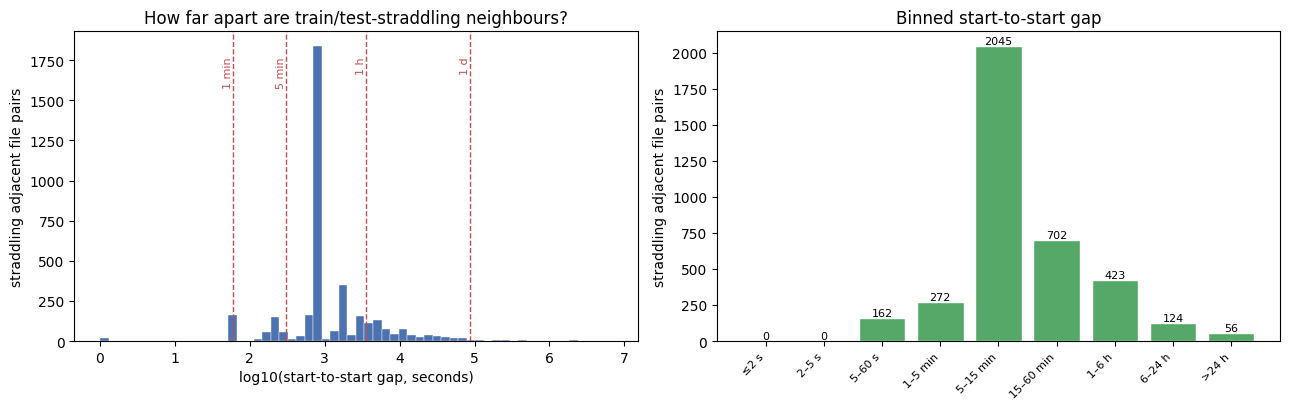

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

s2s = adj["start_to_start_s"].clip(lower=1)
axes[0].hist(np.log10(s2s), bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
for t, c in [(60, "1 min"), (300, "5 min"), (3600, "1 h"), (86400, "1 d")]:
    axes[0].axvline(np.log10(t), color="#C44E52", ls="--", lw=1)
    axes[0].text(np.log10(t), axes[0].get_ylim()[1] * 0.92, c, rotation=90,
                 va="top", ha="right", fontsize=8, color="#C44E52")
axes[0].set_xlabel("log10(start-to-start gap, seconds)")
axes[0].set_ylabel("straddling adjacent file pairs")
axes[0].set_title("How far apart are train/test-straddling neighbours?")

order = ["≤2 s", "2–5 s", "5–60 s", "1–5 min", "5–15 min", "15–60 min", "1–6 h", "6–24 h", ">24 h"]
counts = by_s2s.value_counts().reindex(order)
axes[1].bar(range(len(order)), counts.values, color="#55A868", edgecolor="white")
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("straddling adjacent file pairs")
axes[1].set_title("Binned start-to-start gap")
for i, v in enumerate(counts.values):
    axes[1].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()

## 6 · Nearest train file to every test file (same instrument)

For each test-bearing file, the time to the closest train-bearing file on the same instrument.
This is the "how isolated is the holdout, really" view.

test files                                  : 2,396
  on an instrument with no train file       : 9

  nearest train file within     5 s :    15  (0.6%)
  nearest train file within   5 min :   310  (12.9%)
  nearest train file within  1 hour : 2,166  (90.4%)
  nearest train file within   1 day : 2,373  (99.0%)
  nearest train file within  1 week : 2,381  (99.4%)


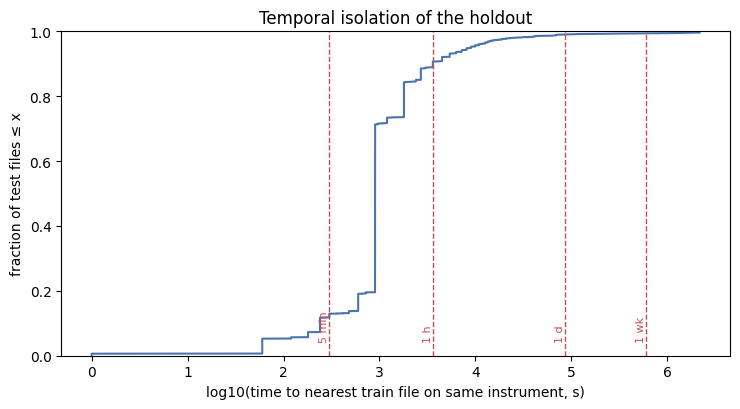

In [11]:
starts_by_inst = {inst: np.sort(g["start"].values.astype("datetime64[ns]"))
                  for inst, g in files[files.bears_train].groupby("instrument")}

nearest = []
for _, r in files[files.bears_test].iterrows():
    arr = starts_by_inst.get(r["instrument"])
    if arr is None or len(arr) == 0:
        nearest.append(np.nan)
        continue
    t = np.datetime64(r["start"].to_datetime64())
    pos = np.searchsorted(arr, t)
    cands = []
    if pos < len(arr):
        cands.append(abs((arr[pos] - t) / np.timedelta64(1, "s")))
    if pos > 0:
        cands.append(abs((t - arr[pos - 1]) / np.timedelta64(1, "s")))
    nearest.append(min(cands) if cands else np.nan)
nearest = pd.Series(nearest, index=files.index[files.bears_test], dtype="float64")

n_test = len(nearest)
n_isolated = nearest.isna().sum()
print(f"test files                                  : {n_test:,}")
print(f"  on an instrument with no train file       : {n_isolated:,}")
print()
for thr, name in [(5, "5 s"), (300, "5 min"), (3600, "1 hour"), (86400, "1 day"), (7 * 86400, "1 week")]:
    n = (nearest <= thr).sum()
    print(f"  nearest train file within {name:>7} : {n:>5,}  ({n / n_test:.1%})")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
vals = np.sort(nearest.dropna().clip(lower=1).values)
ax.plot(np.log10(vals), np.arange(1, len(vals) + 1) / n_test, color="#4C72B0")
for t, c in [(300, "5 min"), (3600, "1 h"), (86400, "1 d"), (7 * 86400, "1 wk")]:
    ax.axvline(np.log10(t), color="#C44E52", ls="--", lw=1)
    ax.text(np.log10(t), 0.05, c, rotation=90, ha="right", color="#C44E52", fontsize=8)
ax.set_xlabel("log10(time to nearest train file on same instrument, s)")
ax.set_ylabel("fraction of test files ≤ x")
ax.set_title("Temporal isolation of the holdout")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 7 · One acoustic instance split across a file boundary

A real detection (non-`Background`) can be cut by the file boundary: it runs to the end of file A
and continues at the start of the next file B. Treat it as **one instance seen twice** when

- **A and B are contiguous** on the same instrument — `start(B) − start(A)` equals A's recorded
  length to within `CONTIG_TOL` (one grid window of slack), so there is no recording gap;
- A has a non-`Background` annotation ending within `EDGE_TOL` s of the boundary;
- B has a non-`Background` annotation of the **same `Labels` class** starting within `EDGE_TOL` s
  of its start.

`freq-matched` additionally requires the two halves' `[LowFreqHz, HighFreqHz]` bands to overlap —
a stricter "same call" test. `cross-split` = the two halves land in different `fold_0` values, i.e.
the same call is physically in both `train` and `test`.

*Caveats:* this is a heuristic, not a labelled fact — a genuinely new call can start right after a
file cut. File length is taken from the end of the `Background` analysis grid; the few files with no
`Background` window fall back to "last detection", which can't distinguish a call at the true file
end from one earlier — those are flagged `detections_only`.

In [12]:
CONTIG_TOL = 6.0    # s  – how far start(B)-start(A) may exceed A's recorded length and still be "contiguous"
EDGE_TOL   = 0.6    # s  – how close to the cut an annotation must sit to count as touching it

ev = df[df["Labels"] != "Background"].copy()
ev["LowFreqHz"]  = pd.to_numeric(ev["LowFreqHz"], errors="coerce")
ev["HighFreqHz"] = pd.to_numeric(ev["HighFreqHz"], errors="coerce")

# file length: prefer the end of the Background analysis grid (independent of the detections);
# fall back to max FileEndSec over all rows when a file has no Background window.
bg_len  = df.loc[df["Labels"] == "Background"].groupby("Soundfile")["FileEndSec"].max()
all_len = df.groupby("Soundfile")["FileEndSec"].max()
file_len = bg_len.reindex(all_len.index)
len_src = np.where(file_len.notna(), "grid", "detections_only")
file_len = file_len.fillna(all_len)
len_src = pd.Series(len_src, index=all_len.index)
ev["file_len"] = ev["Soundfile"].map(file_len)
ev["len_src"]  = ev["Soundfile"].map(len_src)

# candidate edge annotations: touching the trailing edge / leading edge of their own file
tail_all = ev[ev["file_len"] - ev["FileEndSec"] <= EDGE_TOL]
head_all = ev[ev["FileBeginSec"] <= EDGE_TOL]
tail_by_file = {sf: g for sf, g in tail_all.groupby("Soundfile")}
head_by_file = {sf: g for sf, g in head_all.groupby("Soundfile")}

def _bands_overlap(a, b):
    if not np.isfinite(a[0]) or not np.isfinite(b[0]):
        return True                       # missing band -> don't exclude on frequency
    return (a[0] <= b[1]) and (b[0] <= a[1])

rows = []
for inst, gg in files.sort_values("start").groupby("instrument", sort=False):
    gg = gg.reset_index(drop=True)
    for i in range(len(gg) - 1):
        A, B = gg.loc[i], gg.loc[i + 1]
        s2s = (B.start - A.start).total_seconds()
        lae = A.last_anno_end if np.isfinite(A.last_anno_end) else np.nan
        if not np.isfinite(lae):
            continue
        rec_gap = s2s - lae                       # >0: B starts after A's content; <0: overlap
        if not (-CONTIG_TOL <= rec_gap <= CONTIG_TOL):
            continue
        tA = tail_by_file.get(A.Soundfile)
        hB = head_by_file.get(B.Soundfile)
        if tA is None or hB is None:
            continue
        for cls in set(tA["Labels"]) & set(hB["Labels"]):
            ca = tA[tA["Labels"] == cls]
            cb = hB[hB["Labels"] == cls]
            n_cls = min(len(ca), len(cb))
            ba = ca[["LowFreqHz", "HighFreqHz"]].to_numpy()
            bb = cb[["LowFreqHz", "HighFreqHz"]].to_numpy()
            n_freq = sum(any(_bands_overlap(x, y) for y in bb) for x in ba)
            n_freq = min(n_freq, len(cb))
            folds = set(ca["fold_0"]) | set(cb["fold_0"])
            rows.append({
                "dataset": inst.split(" / ")[0], "instrument": inst,
                "file_A": A.Soundfile, "file_B": B.Soundfile, "class": cls,
                "n_instances": int(n_cls), "n_freq_matched": int(n_freq),
                "rec_gap_s": round(rec_gap, 2), "len_src_A": ca["len_src"].iloc[0],
                "fold_A": "/".join(sorted(set(ca["fold_0"]))),
                "fold_B": "/".join(sorted(set(cb["fold_0"]))),
                "cross_split": len(folds) > 1,
                "A_endsec": round(float(ca["FileEndSec"].max()), 2),
                "A_len": round(float(A.last_anno_end), 2),
                "B_beginsec": round(float(cb["FileBeginSec"].min()), 2),
            })
span = pd.DataFrame(rows)
n_contig_events = int(span["n_instances"].sum()) if len(span) else 0
n_freq_events   = int(span["n_freq_matched"].sum()) if len(span) else 0
n_cross         = int(span.loc[span["cross_split"], "n_instances"].sum()) if len(span) else 0
n_cross_freq    = int(span.loc[span["cross_split"], "n_freq_matched"].sum()) if len(span) else 0

n_weak = int(span.loc[span["len_src_A"] == "detections_only", "n_instances"].sum()) if len(span) else 0
print(f"contiguous file pairs with a same-class annotation on both edges : {len(span):,}")
print(f"boundary-spanning instances  (class match)                       : {n_contig_events:,}")
print(f"boundary-spanning instances  (class + frequency-band overlap)    : {n_freq_events:,}")
print(f"  ... of those, halves in different splits (train vs test)       : {n_cross:,}  (class)   {n_cross_freq:,}  (freq-matched)")
print(f"  ... relying on a detections-only file-length estimate (weaker) : {n_weak:,}")

contiguous file pairs with a same-class annotation on both edges : 114
boundary-spanning instances  (class match)                       : 115
boundary-spanning instances  (class + frequency-band overlap)    : 83
  ... of those, halves in different splits (train vs test)       : 52  (class)   35  (freq-matched)
  ... relying on a detections-only file-length estimate (weaker) : 28


In [13]:
if len(span):
    print("By class:")
    print(span.groupby("class")[["n_instances", "n_freq_matched"]].sum()
             .sort_values("n_instances", ascending=False).to_string())
    print()
    print("By dataset:")
    print(span.groupby("dataset")[["n_instances", "n_freq_matched"]].sum()
             .sort_values("n_instances", ascending=False).to_string())
    print()
    print("Cross-split spanning instances (same call physically in train AND test):")
    cs = span[span["cross_split"]].sort_values(["dataset", "file_A"])
    cols = ["dataset", "file_A", "fold_A", "file_B", "fold_B", "class",
            "n_instances", "n_freq_matched", "A_endsec", "A_len", "B_beginsec", "rec_gap_s"]
    print(cs[cols].head(40).to_string(index=False))
else:
    print("No boundary-spanning instances found under the current tolerances.")

By class:
        n_instances  n_freq_matched
class                              
AB               71              60
SRKW             36              16
KW_und            4               4
HW                3               2
TKW               1               1

By dataset:
                 n_instances  n_freq_matched
dataset                                     
Tekteksen                 80              61
LimeKiln                   9               9
SwanChan                   9               4
bush_point                 5               5
StrGeoN1                   4               0
CarmanahPt                 3               0
StrGeoS2                   2               1
StraitofGeorgia            1               1
orcasound_lab              1               1
port_townsend              1               1

Cross-split spanning instances (same call physically in train AND test):
   dataset                                                           file_A fold_A                             

In [14]:
# sensitivity to EDGE_TOL (contiguity fixed at CONTIG_TOL)
def count_spanning(edge_tol):
    tA_ = ev[ev["file_len"] - ev["FileEndSec"] <= edge_tol]
    hB_ = ev[ev["FileBeginSec"] <= edge_tol]
    tbf = {sf: set(g["Labels"]) for sf, g in tA_.groupby("Soundfile")}
    hbf = {sf: set(g["Labels"]) for sf, g in hB_.groupby("Soundfile")}
    n = 0
    for inst, gg in files.sort_values("start").groupby("instrument", sort=False):
        gg = gg.reset_index(drop=True)
        for i in range(len(gg) - 1):
            A, B = gg.loc[i], gg.loc[i + 1]
            lae = A.last_anno_end
            if not np.isfinite(lae):
                continue
            rec_gap = (B.start - A.start).total_seconds() - lae
            if not (-CONTIG_TOL <= rec_gap <= CONTIG_TOL):
                continue
            n += len(tbf.get(A.Soundfile, set()) & hbf.get(B.Soundfile, set()))
    return n

print("EDGE_TOL (s) -> distinct (file-pair, class) boundary matches")
for et in [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]:
    print(f"  {et:>4} : {count_spanning(et):,}")

EDGE_TOL (s) -> distinct (file-pair, class) boundary matches


   0.1 : 78


  0.25 : 85


   0.5 : 109


   1.0 : 138


   2.0 : 178


   5.0 : 262


## 8 · Summary

In [15]:
n_test_files = int(files["bears_test"].sum())
summary = f'''
TRAIN / TEST TEMPORAL OVERLAP  —  full_train split, annotations.csv base
========================================================================
annotations joined to a split     : {len(df):,}
audio files (with recovered time) : {len(files):,}   train_only={int((files.cls=='train_only').sum()):,}  test_only={int((files.cls=='test_only').sum()):,}  mixed={int((files.cls=='mixed').sum()):,}

1. File-level contamination (a file with both train & test segments)
   mixed files ............................ {int((files.cls=='mixed').sum()):,}

2. Shared clock-hour buckets (same instrument)
   leaky hour buckets .................... {len(leak_hour):,}
   test files sharing an hour with train . {int(leak_hour['n_test_files'].sum()):,}  ({leak_hour['n_test_files'].sum()/n_test_files:.1%} of test files)

3. Shared clock-day buckets (same instrument)
   leaky day buckets .................... {len(leak_day):,}
   test files sharing a day with train .. {int(leak_day['n_test_files'].sum()):,}  ({leak_day['n_test_files'].sum()/n_test_files:.1%} of test files)

4. Adjacent files straddling the split (same instrument, sorted by time)
   straddling adjacent pairs ............ {len(adj):,}
   ... starting within 5 s ............. {(adj['start_to_start_s']<=5).sum():,}
   ... starting within 5 min .......... {(adj['start_to_start_s']<=300).sum():,}
   ... starting within 1 h ........... {(adj['start_to_start_s']<=3600).sum():,}
   ... contiguous audio (rec. gap <=5s) {(adj['recording_gap_s']<=5).sum():,}

5. Nearest train file to each test file (same instrument)
   test file has a train file within 5 min : {(nearest<=300).sum():,}  ({(nearest<=300).sum()/n_test_files:.1%})
   ................................ 1 hour : {(nearest<=3600).sum():,}  ({(nearest<=3600).sum()/n_test_files:.1%})
   ................................. 1 day : {(nearest<=86400).sum():,}  ({(nearest<=86400).sum()/n_test_files:.1%})

6. One acoustic instance split across a contiguous file boundary (non-Background)
   spanning instances (same class) ........ {n_contig_events:,}
   spanning instances (class + freq band)  {n_freq_events:,}
   ... halves in different splits ......... {n_cross:,}  (class)   {n_cross_freq:,}  (freq-matched)
'''
print(summary)


TRAIN / TEST TEMPORAL OVERLAP  —  full_train split, annotations.csv base
annotations joined to a split     : 1,180,083
audio files (with recovered time) : 13,073   train_only=10,677  test_only=2,396  mixed=0

1. File-level contamination (a file with both train & test segments)
   mixed files ............................ 0

2. Shared clock-hour buckets (same instrument)
   leaky hour buckets .................... 1,415
   test files sharing an hour with train . 1,899  (79.3% of test files)

3. Shared clock-day buckets (same instrument)
   leaky day buckets .................... 471
   test files sharing a day with train .. 2,359  (98.5% of test files)

4. Adjacent files straddling the split (same instrument, sorted by time)
   straddling adjacent pairs ............ 3,804
   ... starting within 5 s ............. 20
   ... starting within 5 min .......... 454
   ... starting within 1 h ........... 3,201
   ... contiguous audio (rec. gap <=5s) 396

5. Nearest train file to each test file (s